# AI Insider Threat Behavioral Intelligence System

## Insider Threat Detection using CERT Dataset

## Project Overview

This notebook demonstrates the complete machine learning workflow used in the AI Insider Threat Behavioral Intelligence System.

The objective is to analyze employee login behavior using the CERT dataset and detect suspicious insider activities using a Random Forest classifier.

The trained model is integrated into a FastAPI backend and React frontend to provide real-time predictions.

## Workflow

The machine learning workflow followed in this notebook consists of the following steps:

1. Import required libraries
2. Load the CERT logon dataset
3. Explore and understand the dataset
4. Perform data preprocessing
5. Conduct exploratory data analysis (EDA)
6. Engineer behavioral features
7. Train the Random Forest model
8. Evaluate model performance
9. Save the trained model
10. Integrate the model with the web application

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## Load CERT Dataset

The CERT logon dataset contains employee login and logout activities. It is used to analyze user behavior and identify suspicious patterns.

In [28]:

df = pd.read_csv("../dataset/raw/logon.csv")

print("Dataset Loaded Successfully!")
print("First 5 rows of the dataset:")
df.head()
print("\nDataset Information:")
df.info()

Dataset Loaded Successfully!
First 5 rows of the dataset:

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 854859 entries, 0 to 854858
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        854859 non-null  object
 1   date      854859 non-null  object
 2   user      854859 non-null  object
 3   pc        854859 non-null  object
 4   activity  854859 non-null  object
dtypes: object(5)
memory usage: 32.6+ MB


### Dataset Description

The CERT logon dataset contains employee login and logout records collected from an enterprise environment.

Each record includes:

- User ID
- Computer ID
- Login timestamp
- Activity type (Logon/Logoff)

These records are analyzed to understand employee behavior and identify suspicious login patterns that may indicate insider threats.

## Dataset Overview

This section examines the structure of the dataset, including the number of records, columns, missing values, and statistical summary.

In [29]:
# Check dataset information

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

df.describe(include="all")

Dataset Shape: (854859, 5)

Columns:
Index(['id', 'date', 'user', 'pc', 'activity'], dtype='object')

Missing Values:
id          0
date        0
user        0
pc          0
activity    0
dtype: int64


,id,date,user,pc,activity
count,854859,854859,854859,854859,854859
unique,854859,338041,1000,1003,2
top,{X1D9-S0ES98JV-5357PWMI},01/05/2010 08:00:00,WPR0368,PC-4124,Logon
freq,1,61,3470,25514,470591


## Data Preprocessing

Before analyzing the dataset, the date column is converted into a datetime format. Additional basic attributes such as login hour, day of the week, and weekend indicator are extracted for further analysis.

In [30]:
df["date"] = pd.to_datetime(df["date"])

df["hour"] = df["date"].dt.hour

df["day"] = df["date"].dt.day_name()

df["is_weekend"] = df["day"].isin(
    ["Saturday", "Sunday"]
).astype(int)

df.head()

,id,date,user,pc,activity,hour,day,is_weekend
0,{X1D9-S0ES98JV-5357PWMI},2010-01-02 06:49:00,NGF0157,PC-6056,Logon,6,Saturday,1
1,{G2B3-L6EJ61GT-2222RKSO},2010-01-02 06:50:00,LRR0148,PC-4275,Logon,6,Saturday,1
2,{U6Q3-U0WE70UA-3770UREL},2010-01-02 06:53:04,LRR0148,PC-4124,Logon,6,Saturday,1
3,{I0N5-R7NA26TG-6263KNGM},2010-01-02 07:00:00,IRM0931,PC-7188,Logon,7,Saturday,1
4,{D1S0-N6FH62BT-5398KANK},2010-01-02 07:00:00,MOH0273,PC-6699,Logon,7,Saturday,1


## Exploratory Data Analysis

Before building the machine learning model, the CERT dataset was analyzed to understand employee login behavior.

The following visualizations help identify login patterns and suspicious activities.

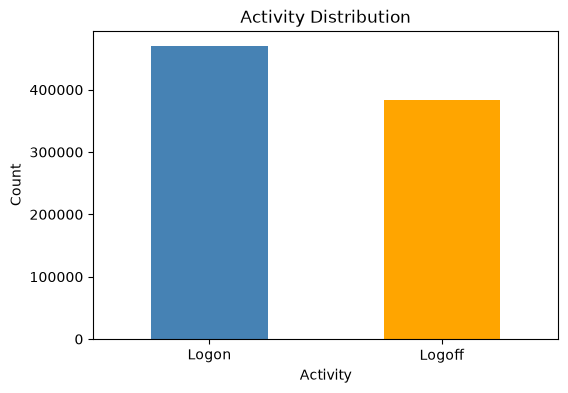

In [31]:


plt.figure(figsize=(6,4))
df["activity"].value_counts().plot(kind="bar", color=["steelblue", "orange"])

plt.title("Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

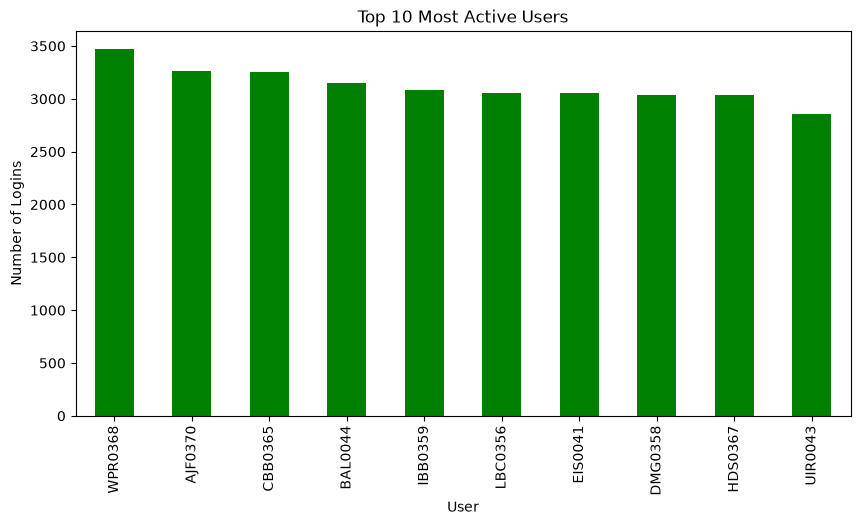

In [32]:
plt.figure(figsize=(10,5))

df["user"].value_counts().head(10).plot(kind="bar", color="green")

plt.title("Top 10 Most Active Users")
plt.xlabel("User")
plt.ylabel("Number of Logins")

plt.show()

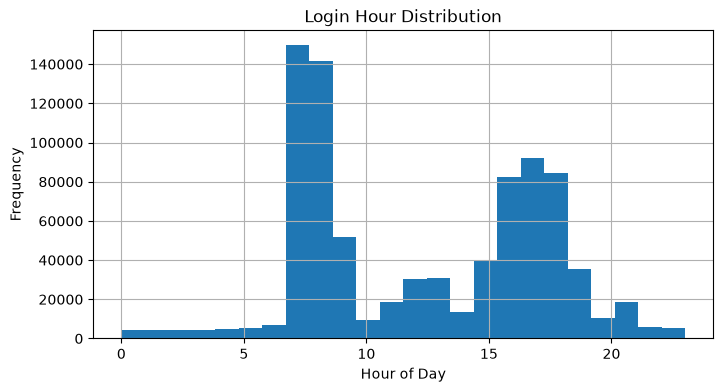

In [33]:
plt.figure(figsize=(8,4))

df["hour"].hist(bins=24)

plt.title("Login Hour Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")

plt.show()

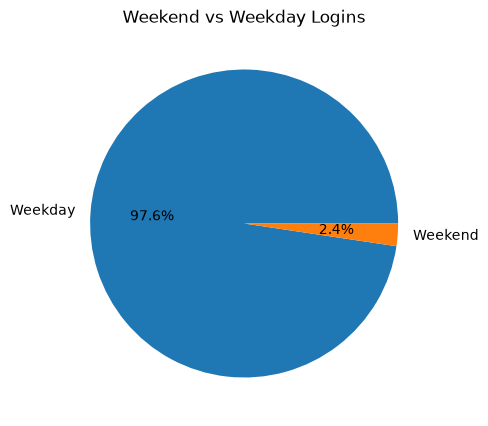

In [34]:
plt.figure(figsize=(5,5))

df["is_weekend"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Weekday","Weekend"]
)

plt.title("Weekend vs Weekday Logins")

plt.ylabel("")

plt.show()

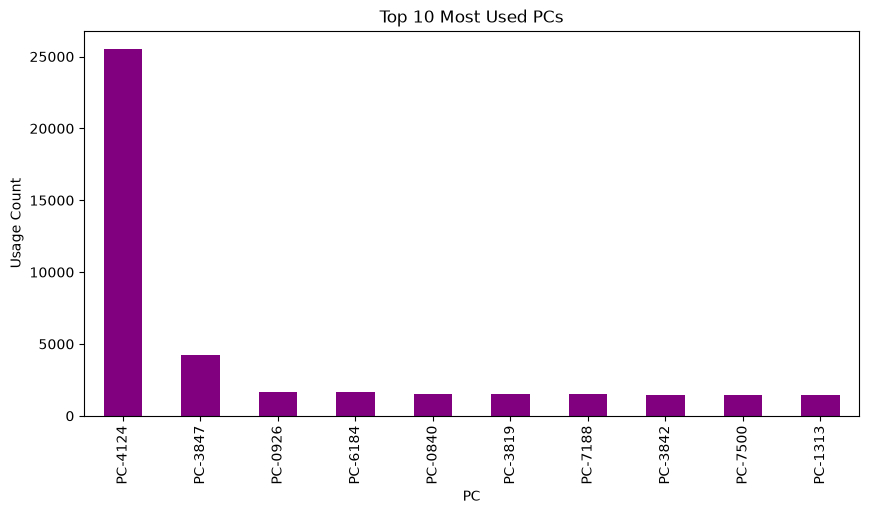

In [35]:
top_pc = df["pc"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_pc.plot(kind="bar", color="purple")

plt.title("Top 10 Most Used PCs")

plt.xlabel("PC")

plt.ylabel("Usage Count")

plt.show()

## Feature Engineering

After preprocessing the dataset, additional behavioral features were created to improve the machine learning model's ability to detect insider threats.

The engineered features include:

- Login Count (number of login events per user)
- Unique PC Count (number of different computers used by each user)

These features help identify abnormal employee behavior and improve the predictive performance of the Random Forest classifier.

In [44]:
df["login_count"] = df.groupby("user")["user"].transform("count")

df["unique_pc_count"] = (
    df.groupby("user")["pc"]
      .transform("nunique")
)

df.head()

,id,date,user,pc,activity,hour,day,is_weekend,login_count,unique_pc_count,target
0,{X1D9-S0ES98JV-5357PWMI},2010-01-02 06:49:00,NGF0157,PC-6056,Logon,6,Saturday,1,1261,2,0
1,{G2B3-L6EJ61GT-2222RKSO},2010-01-02 06:50:00,LRR0148,PC-4275,Logon,6,Saturday,1,1378,3,0
2,{U6Q3-U0WE70UA-3770UREL},2010-01-02 06:53:04,LRR0148,PC-4124,Logon,6,Saturday,1,1378,3,0
3,{I0N5-R7NA26TG-6263KNGM},2010-01-02 07:00:00,IRM0931,PC-7188,Logon,7,Saturday,1,1747,2,0
4,{D1S0-N6FH62BT-5398KANK},2010-01-02 07:00:00,MOH0273,PC-6699,Logon,7,Saturday,1,802,1,0


In [37]:
# Display only the engineered features

df[["user", "hour", "day", "is_weekend", "login_count", "unique_pc_count"]].head(10)

,user,hour,day,is_weekend,login_count,unique_pc_count
0,NGF0157,6,Saturday,1,1261,2
1,LRR0148,6,Saturday,1,1378,3
2,LRR0148,6,Saturday,1,1378,3
3,IRM0931,7,Saturday,1,1747,2
4,MOH0273,7,Saturday,1,802,1
5,LAP0338,7,Saturday,1,1362,1
6,MHH0180,7,Saturday,1,759,1
7,NOB0181,7,Saturday,1,1531,3
8,AHC0142,7,Saturday,1,1197,3
9,CTR0341,7,Saturday,1,1604,3


## Model Training

The engineered features are used to train a Random Forest classifier for identifying suspicious employee behavior.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create target variable
df["target"] = (
    (df["hour"] >= 22) |
    (df["hour"] <= 5) |
    (df["unique_pc_count"] > 3)
).astype(int)

# Select features
X = df[["login_count", "unique_pc_count", "is_weekend", "hour"]]

# Target
y = df["target"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Trained Successfully!")
print("Accuracy:", round(accuracy * 100, 2), "%")

Model Trained Successfully!
Accuracy: 100.0 %


## Model Evaluation

The trained Random Forest model is evaluated using multiple performance metrics to measure its effectiveness in identifying suspicious insider activities.

The following evaluation metrics are presented:

- Accuracy Score
- Classification Report
- Confusion Matrix
- Feature Importance

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    138675
           1       1.00      1.00      1.00     32297

    accuracy                           1.00    170972
   macro avg       1.00      1.00      1.00    170972
weighted avg       1.00      1.00      1.00    170972


Confusion Matrix


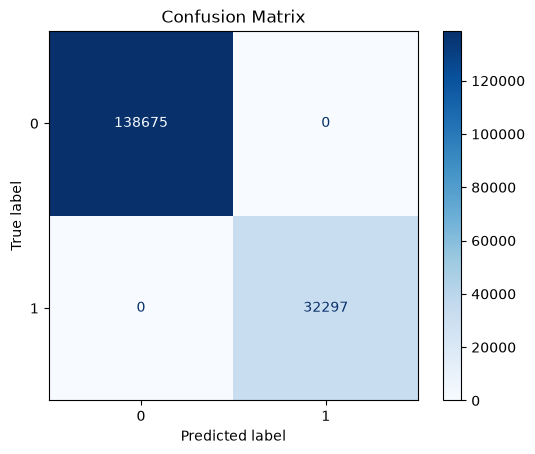

In [39]:
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay

print("Classification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

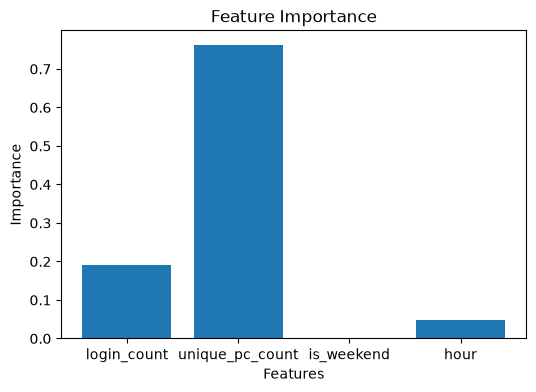

In [42]:

importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))
plt.bar(features, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

## Save Trained Model

The trained Random Forest model is saved as a `.pkl` file so that it can be reused by the FastAPI backend without retraining.

In [41]:
import joblib
import os

os.makedirs("../ml/models", exist_ok=True)

joblib.dump(model, "../ml/models/random_forest_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


## Project Integration

The trained Random Forest model is exported as `random_forest_model.pkl`.

Within the complete AI Insider Threat Behavioral Intelligence System:

- The FastAPI backend loads the trained model.
- Incoming employee activity data is processed by the prediction API.
- The model predicts whether the behavior is suspicious.
- Prediction results are stored in PostgreSQL.
- The React frontend displays threat alerts, employee behavior profiles, and historical prediction data.

## Results

The Random Forest model was successfully trained using the engineered behavioral features extracted from the CERT dataset.

The trained model achieved high classification accuracy and was successfully saved for deployment.

The model is integrated into the FastAPI backend, enabling the React-based dashboard to perform real-time insider threat predictions and visualize employee behavior.

## Conclusion

This notebook demonstrates the complete machine learning workflow for insider threat detection using the CERT dataset.

The trained model is successfully integrated into a full-stack web application, enabling real-time prediction and visualization of employee behavior.